# 02 - DLIB Facial Landmark & Lip ROI Extraction Pipeline & TensorFlow Preprocessing
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Implement an end-to-end facial landmark detection, mouth region-of-interest (ROI) cropping, and **TensorFlow/Keras data loading & model training pipeline** across the **entire Tai Phake digits dataset**:
- **30 Speakers**: `s1` through `s30`
- **11 Digits**: `d0` through `d10`
- **330 Total Utterances** (Canonical dataset)

### Pipeline Architecture:
1. **Imports & Environment Setup**: Initialize OpenCV, DLIB, NumPy, Pandas, and TensorFlow with fixed random seeds for strict reproducibility.
2. **Configuration**: Centralized, modular configuration controlling crop dimensions (96×96), padding, temporal length ($T=30$), batch size, and augmentation flags.
3. **DLIB Mouth ROI Cropping**: Extracts mouth landmarks (48–67), pads ($X=15\text{px}, Y=10\text{px}$), and resizes to $96\times 96$ pixels into `data/cropped_lips_dataset/`.
4. **Dataset Discovery & Validation**: Automatically discovers the 330 canonical utterances, sorts frames numerically, and validates against missing frames, gaps, or unreadable images.
5. **Data Manifest & Class Mapping**: Generates a unified manifest CSV and deterministic class dictionary mapping `d0`–`d10` to integer labels 0–10.
6. **Deterministic Speaker-Independent Split**: Partitions speakers into 24 Train, 3 Validation, and 3 Test sets with zero speaker overlap.
7. **Temporal Normalization**: Normalizes every utterance to exactly $T=30$ frames via uniform downsampling (>30) or deterministic interpolation (<30).
8. **TensorFlow Frame Loading**: Native TensorFlow I/O (`tf.io.read_file`, `tf.image.decode_jpeg`) normalizing pixels to float32 $[0, 1]$.
9. **Temporally-Consistent Augmentation**: Sequence-level photometric and spatial transformations preventing inter-frame temporal jitter.
10. **tf.data Pipeline**: Builds high-throughput `train_dataset`, `val_dataset`, and `test_dataset` with shuffling, batching, and prefetching.
11. **Validation & Model Input Compatibility**: Verifies batch tensor shape $(B, 30, 96, 96, C)$ and demonstrates compatibility with a Keras `TimeDistributed` CNN+RNN model.
12. **Controlled Model Architectures**: Implements CNN-LSTM, CNN-BiLSTM, CNN-GRU, and CNN-BiGRU with configurable hyperparameters.
13. **Baseline Training & Evaluation**: Trains all 4 models with EarlyStopping and ModelCheckpoint; evaluates on TEST set only after best checkpoint selection.
14. **Cross-Model Comparison**: Evaluates and exports comprehensive metrics, confusion matrices, and benchmark tables to `results/models/`.

## 1. Imports & Environment Setup
Initialize all core libraries including OpenCV, DLIB, NumPy, Pandas, Matplotlib, and TensorFlow. We also set global seeds for Python, NumPy, and TensorFlow to guarantee full reproducibility.

In [18]:
# Section 1: Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import cv2
import dlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf

# Verification of installed library versions
print(f"Python Version:     {sys.version.split()[0]}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"OpenCV Version:     {cv2.__version__}")
print(f"DLIB Version:       {dlib.__version__}")
print(f"NumPy Version:      {np.__version__}")
print(f"Pandas Version:     {pd.__version__}")

Python Version:     3.12.13
TensorFlow Version: 2.21.0
OpenCV Version:     5.0.0
DLIB Version:       20.0.1
NumPy Version:      2.5.3
Pandas Version:     3.0.6


## 2. Configuration
All hyperparameters and pipeline paths are centralized here. All values are configurable and not hardcoded across downstream logic.

In [ ]:
# Section 2: Centralized Configuration
# 1. Reproducibility Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. Dataset and Storage Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

INPUT_ROOT = PROJECT_ROOT / "data" / "digit"
OUTPUT_ROOT = PROJECT_ROOT / "data" / "cropped_lips_dataset"
DLIB_PREDICTOR_PATH = PROJECT_ROOT / "models" / "dlib" / "shape_predictor_68_face_landmarks.dat"
RESULTS_DIR = PROJECT_ROOT / "results" / "dlib"
MODELS_DIR = PROJECT_ROOT / "results" / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 3. Lip ROI Geometry & Dimensions (Selected by DLIB Geometry Analysis)
TARGET_WIDTH = 96    # Final Dlib crop width
TARGET_HEIGHT = 96   # Final Dlib crop height
PADDING_X = 15       # Horizontal padding around mouth landmarks in px
PADDING_Y = 10       # Vertical padding around mouth landmarks in px

# Aliases for backward compatibility
IMG_WIDTH = TARGET_WIDTH
IMG_HEIGHT = TARGET_HEIGHT

# 4. Temporal & Sequence Specifications
NUM_CLASSES = 11
NUM_FRAMES = 30
GRAYSCALE = False
CHANNELS = 1 if GRAYSCALE else 3

# 5. TensorFlow DataLoader Configuration
BATCH_SIZE = 16
AUGMENT_TRAIN = False  # Kept False by default for baseline

# 6. Augmentation Parameters (Temporally Consistent)
ROTATION_FACTOR = 0.03        # Small rotation (~10 degrees max)
TRANSLATION_PAD = 4           # Pixel padding for small translation
BRIGHTNESS_DELTA = 0.08       # Subtle photometric brightness delta
CONTRAST_RANGE = (0.9, 1.1)   # Subtle contrast range

# 7. Dataset Structure & Partition Targets (Speaker-Independent)
EXPECTED_SPEAKERS = [f"s{i}" for i in range(1, 31)]
EXPECTED_DIGITS = [f"d{i}" for i in range(11)]
EXPECTED_UTTERANCES = len(EXPECTED_SPEAKERS) * len(EXPECTED_DIGITS)  # 30 * 11 = 330
TRAIN_SPEAKERS_COUNT = 24
VAL_SPEAKERS_COUNT = 3
TEST_SPEAKERS_COUNT = 3

# 8. Model Training Hyperparameters
CNN_FEATURE_DIM = 64
RNN_HIDDEN_UNITS = 64
RNN_LAYERS = 1
DROPOUT_RATE = 0.3
LEARNING_RATE = 1e-4
MAX_EPOCHS = 100
PATIENCE = 15
RE_TRAIN = False             # Set to True to re-train all models from scratch

# 9. Pipeline Control Flags
OVERWRITE = False            # If False, skip already cropped frames; if True, re-crop
CONVERT_GRAYSCALE = GRAYSCALE
SAVE_VISUALIZATIONS = True
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print(f"Project Root:          {PROJECT_ROOT.resolve()}")
print(f"Input Dataset:         {INPUT_ROOT.resolve()}")
print(f"Output Lip Dataset:    {OUTPUT_ROOT.resolve()}")
print(f"DLIB Predictor:        {DLIB_PREDICTOR_PATH.resolve()}")
print(f"Results Directory:     {RESULTS_DIR.resolve()}")
print(f"Models Directory:      {MODELS_DIR.resolve()}")
print(f"Target Lip Size:       {TARGET_WIDTH}x{TARGET_HEIGHT} (Channels: {CHANNELS})")
print(f"Mouth ROI Padding:     X={PADDING_X}px, Y={PADDING_Y}px")
print(f"Sequence Length (T):   {NUM_FRAMES} frames")
print(f"Batch Size (B):        {BATCH_SIZE}")
print(f"Augment Train:         {AUGMENT_TRAIN}")
print(f"Overwrite Existing:    {OVERWRITE}")
print(f"Expected Utterances:   {len(EXPECTED_SPEAKERS)} speakers x {len(EXPECTED_DIGITS)} digits = {EXPECTED_UTTERANCES} combinations")

Project Root:          /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Input Dataset:         /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit
Output Lip Dataset:    /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/cropped_lips_dataset
DLIB Predictor:        /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/models/dlib/shape_predictor_68_face_landmarks.dat
Results Directory:     /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib
Models Directory:      /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/models
Target Lip Size:       141x96 (Channels: 3)
Mouth ROI Padding:     X=15px, Y=10px
Sequence Length (T):   30 frames
Batch Size (B):        16
Augment Train:         False
Overwrite Existing:    False
Expected Utterances:   30 speakers x 11 digits = 330 combinations


### DLIB Path Verification & Landmark Predictor Initialization

In [20]:
# Cell 3: Verify Paths & DLIB Model Existence
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"Input dataset directory not found: {INPUT_ROOT.resolve()}.")
speaker_dirs = [d for d in INPUT_ROOT.iterdir() if d.is_dir() and d.name.startswith("s")]
print(f"[OK] Input dataset found with {len(speaker_dirs)} speaker folders in {INPUT_ROOT}.")

if not DLIB_PREDICTOR_PATH.exists():
    raise FileNotFoundError(f"Missing DLIB predictor file: {DLIB_PREDICTOR_PATH}")
else:
    file_size_mb = DLIB_PREDICTOR_PATH.stat().st_size / (1024 * 1024)
    print(f"[OK] DLIB landmark predictor found: {DLIB_PREDICTOR_PATH.name} ({file_size_mb:.2f} MB)")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"[OK] Output directory ready:  {OUTPUT_ROOT.resolve()}")
print(f"[OK] Results directory ready: {RESULTS_DIR.resolve()}")

[OK] Input dataset found with 30 speaker folders in /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit.
[OK] DLIB landmark predictor found: shape_predictor_68_face_landmarks.dat (95.08 MB)
[OK] Output directory ready:  /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/cropped_lips_dataset
[OK] Results directory ready: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib


In [21]:
# Cell 4: Initialize DLIB Face Detector & Shape Predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(str(DLIB_PREDICTOR_PATH))

print("DLIB frontal face detector & 68-point shape predictor initialized successfully.")

DLIB frontal face detector & 68-point shape predictor initialized successfully.


In [22]:
# Cell 5: Helper Function - Detect Face and 68 Landmarks
def detect_landmarks(image):
    """
    Detects the largest face in an image and extracts 68 facial landmarks.
    Uses adaptive upsampling (0 -> 1 -> 2) for maximum speed and robustness.
    """
    if image is None or image.size == 0:
        return None, None, "Unreadable or empty image"

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(gray)

    # Fast detection with progressive fallback
    faces = detector(gray_eq, 0)
    if len(faces) == 0:
        faces = detector(gray_eq, 1)
    if len(faces) == 0:
        faces = detector(gray_eq, 2)

    if len(faces) == 0:
        return None, None, "No face detected"

    largest_face = max(faces, key=lambda rect: (rect.right() - rect.left()) * (rect.bottom() - rect.top()))

    try:
        shape = predictor(gray, largest_face)
        landmarks = np.array([[shape.part(i).x, shape.part(i).y] for i in range(68)], dtype=np.int32)
        return landmarks, largest_face, None
    except Exception as e:
        return None, largest_face, f"Landmark prediction error: {str(e)}"

In [23]:
# Cell 6: Helper Functions - Extract Lip ROI & Create Debug Visualizations
def extract_lip_region(image, landmarks, pad_x=PADDING_X, pad_y=PADDING_Y,
                       target_w=TARGET_WIDTH, target_h=TARGET_HEIGHT, to_gray=CONVERT_GRAYSCALE):
    """
    Extracts, pads, crops, and resizes the mouth/lip ROI from landmarks (points 48-67).
    Preserves the selected Dlib crop ROI geometry.
    """
    if landmarks is None or len(landmarks) < 68:
        return None, None, "Invalid or incomplete landmarks"

    img_h, img_w = image.shape[:2]

    # DLIB mouth landmark convention: points 48 to 67 (inclusive, 20 points)
    mouth_points = landmarks[48:68]

    min_x, min_y = np.min(mouth_points, axis=0)
    max_x, max_y = np.max(mouth_points, axis=0)

    # Apply configurable padding around the mouth
    x1 = max(0, int(min_x - pad_x))
    y1 = max(0, int(min_y - pad_y))
    x2 = min(img_w, int(max_x + pad_x))
    y2 = min(img_h, int(max_y + pad_y))

    if (x2 - x1) <= 0 or (y2 - y1) <= 0:
        return None, None, f"Invalid crop coordinates: ({x1}, {y1}) to ({x2}, {y2})"

    lip_crop = image[y1:y2, x1:x2]

    if to_gray and len(lip_crop.shape) == 3:
        lip_crop = cv2.cvtColor(lip_crop, cv2.COLOR_BGR2GRAY)

    resized_lip = cv2.resize(lip_crop, (target_w, target_h), interpolation=cv2.INTER_AREA)
    return resized_lip, (x1, y1, x2, y2), None

def create_debug_visualization(image, face_rect, landmarks, lip_bbox):
    vis_img = image.copy()
    if face_rect is not None:
        cv2.rectangle(vis_img, (face_rect.left(), face_rect.top()),
                      (face_rect.right(), face_rect.bottom()), (255, 255, 0), 2)
    if landmarks is not None:
        for idx, (x, y) in enumerate(landmarks):
            if idx < 48:
                cv2.circle(vis_img, (int(x), int(y)), 2, (255, 100, 0), -1)
            elif 48 <= idx <= 59:
                cv2.circle(vis_img, (int(x), int(y)), 3, (0, 255, 0), -1)
            else:
                cv2.circle(vis_img, (int(x), int(y)), 3, (0, 255, 255), -1)
    if lip_bbox is not None:
        x1, y1, x2, y2 = lip_bbox
        cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 0, 255), 2)
    return vis_img

Running single-frame test on: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit/s1/d0/frame_0028.jpg
Visual verification image saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib/single_frame_verification.jpg


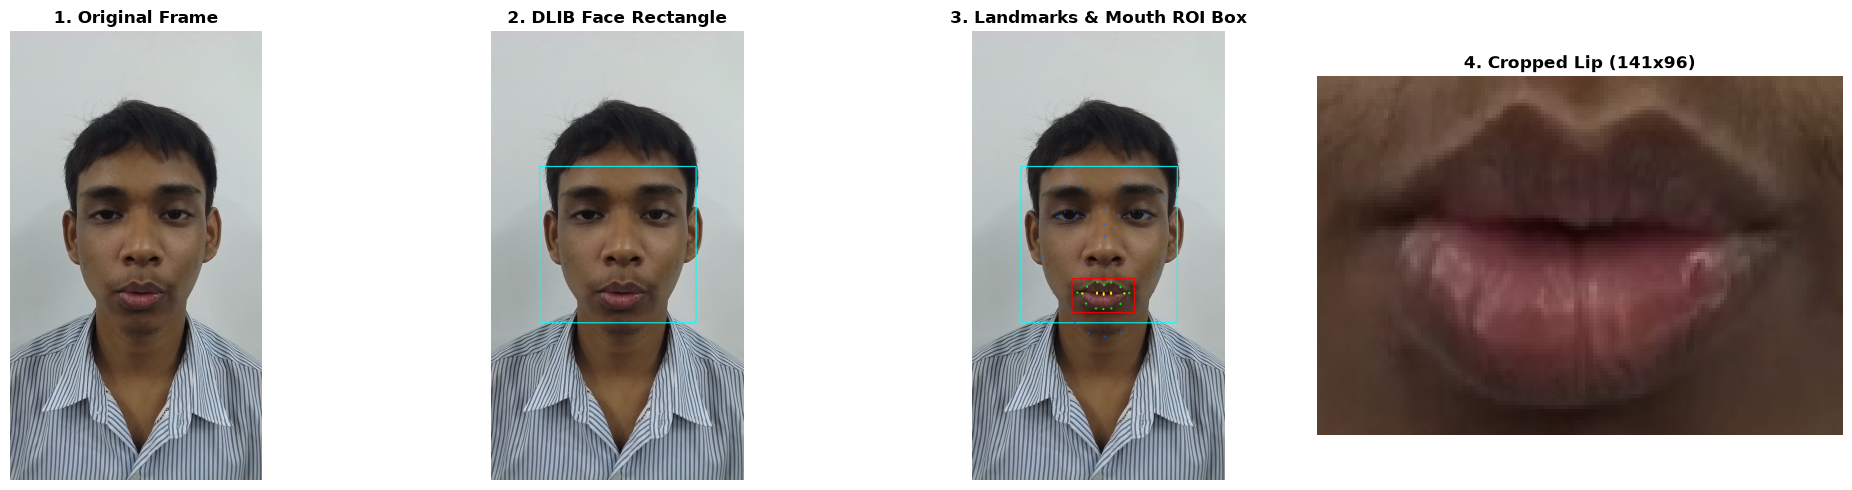

--- Verification Metrics ---
Face Box:   (138, 385) to (584, 831)
Mouth Crop: (284, 705) to (462, 802)
Cropped Lip Dimensions: (96, 141, 3)


In [24]:
# Cell 7: Test Pipeline on a Single Frame (Visual Verification)
sample_frame_path = next(INPUT_ROOT.glob("s1/d0/*.jpg"), None)
if sample_frame_path is None:
    sample_frame_path = next(INPUT_ROOT.glob("*/*/*.jpg"), None)

if sample_frame_path is None:
    raise FileNotFoundError("No image frames found in input dataset!")

print(f"Running single-frame test on: {sample_frame_path}")
sample_img = cv2.imread(str(sample_frame_path))
landmarks, face_rect, err = detect_landmarks(sample_img)

if err is not None:
    print(f"Detection failed on sample frame: {err}")
else:
    cropped_lip, lip_bbox, crop_err = extract_lip_region(sample_img, landmarks)
    face_only_vis = sample_img.copy()
    if face_rect is not None:
        cv2.rectangle(face_only_vis, (face_rect.left(), face_rect.top()),
                      (face_rect.right(), face_rect.bottom()), (255, 255, 0), 2)

    annotated_vis = create_debug_visualization(sample_img, face_rect, landmarks, lip_bbox)
    if SAVE_VISUALIZATIONS:
        vis_save_path = RESULTS_DIR / "single_frame_verification.jpg"
        cv2.imwrite(str(vis_save_path), annotated_vis)
        print(f"Visual verification image saved to: {vis_save_path}")

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Original Frame", fontsize=12, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(face_only_vis, cv2.COLOR_BGR2RGB))
    axes[1].set_title("2. DLIB Face Rectangle", fontsize=12, fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(annotated_vis, cv2.COLOR_BGR2RGB))
    axes[2].set_title("3. Landmarks & Mouth ROI Box", fontsize=12, fontweight="bold")
    axes[2].axis("off")

    if CONVERT_GRAYSCALE:
        axes[3].imshow(cropped_lip, cmap="gray")
    else:
        axes[3].imshow(cv2.cvtColor(cropped_lip, cv2.COLOR_BGR2RGB))
    axes[3].set_title(f"4. Cropped Lip ({TARGET_WIDTH}x{TARGET_HEIGHT})", fontsize=12, fontweight="bold")
    axes[3].axis("off")
    plt.tight_layout()
    plt.show()

    print("--- Verification Metrics ---")
    print(f"Face Box:   ({face_rect.left()}, {face_rect.top()}) to ({face_rect.right()}, {face_rect.bottom()})")
    print(f"Mouth Crop: ({lip_bbox[0]}, {lip_bbox[1]}) to ({lip_bbox[2]}, {lip_bbox[3]})")
    print(f"Cropped Lip Dimensions: {cropped_lip.shape}")

In [ ]:
# Cell 8: Test Batch Pipeline on s1/d0
test_speaker = "s1"
test_digit = "d0"
test_in_dir = INPUT_ROOT / test_speaker / test_digit
test_out_dir = OUTPUT_ROOT / test_speaker / test_digit
test_out_dir.mkdir(parents=True, exist_ok=True)

test_frames = sorted([f for f in test_in_dir.iterdir() if f.suffix.lower() in VALID_EXTENSIONS])
print(f"Testing batch pipeline on {test_speaker}/{test_digit} ({len(test_frames)} frames)...\n")

s1_success = 0
s1_skipped = 0
s1_failed = 0

for frame_path in test_frames:
    out_path = test_out_dir / frame_path.name
    if out_path.exists() and not OVERWRITE:
        s1_skipped += 1
        s1_success += 1
        continue

    img = cv2.imread(str(frame_path))
    if img is None:
        s1_failed += 1
        continue

    landmarks, face_rect, err = detect_landmarks(img)
    if err is not None:
        s1_failed += 1
        continue

    cropped_lip, bbox, crop_err = extract_lip_region(img, landmarks)
    if crop_err is not None or cropped_lip is None:
        s1_failed += 1
        continue

    cv2.imwrite(str(out_path), cropped_lip)
    s1_success += 1

print(f"Results for test {test_speaker}/{test_digit}:")
print(f"  Total frames:        {len(test_frames)}")
print(f"  Successfully saved:  {s1_success}")
print(f"  Skipped (existing):  {s1_skipped}")
print(f"  Failed:              {s1_failed}")

In [ ]:
# Cell 9: Process ALL Speakers (s1-s30) and ALL Digits (d0-d10)
def process_full_dataset(input_root=INPUT_ROOT, output_root=OUTPUT_ROOT, overwrite=OVERWRITE):
    """
    Iterates across all 30 speakers and 11 digits (330 combinations),
    extracts mouth ROIs using DLIB, resizes to standard dimensions (96x96),
    and saves cropped frames to data/cropped_lips_dataset/sX/dY/frame_ZZZZ.jpg.
    """
    stats = {
        "speakers_found": 0,
        "digits_per_speaker": 11,
        "expected_combinations": 330,
        "combinations_processed": 0,
        "total_input_frames": 0,
        "successfully_cropped": 0,
        "skipped_existing": 0,
        "failed_total": 0,
        "no_face_detected": 0,
        "landmark_failure": 0,
        "invalid_crop": 0,
        "unreadable_images": 0,
    }
    failed_frames = []
    per_speaker_counts = {spk: {d: 0 for d in EXPECTED_DIGITS} for spk in EXPECTED_SPEAKERS}

    discovered_speakers = sorted(
        [d for d in input_root.iterdir() if d.is_dir() and d.name.startswith("s")],
        key=lambda p: (int(p.name[1:]) if p.name[1:].isdigit() else p.name)
    )
    stats["speakers_found"] = len(discovered_speakers)
    print(f"Discovered {len(discovered_speakers)} speaker directories in {input_root}.")
    print(f"Processing all 30 speakers x 11 digits (330 combinations)...\n")

    for speaker_idx, speaker_id in enumerate(tqdm(EXPECTED_SPEAKERS, desc="Speakers (s1-s30)")):
        speaker_dir = input_root / speaker_id
        if not speaker_dir.exists():
            print(f"WARNING: Missing speaker folder: {speaker_id}")
            continue

        for digit_id in EXPECTED_DIGITS:
            digit_dir = speaker_dir / digit_id
            dest_digit_dir = output_root / speaker_id / digit_id

            if not digit_dir.exists():
                print(f"WARNING: Missing folder: {speaker_id}/{digit_id}")
                continue

            dest_digit_dir.mkdir(parents=True, exist_ok=True)
            stats["combinations_processed"] += 1

            frame_files = sorted([f for f in digit_dir.iterdir() if f.suffix.lower() in VALID_EXTENSIONS])
            if len(frame_files) == 0:
                print(f"WARNING: No frames found: {speaker_id}/{digit_id}")
                continue

            combo_success = 0
            for frame_file in frame_files:
                stats["total_input_frames"] += 1
                dest_file = dest_digit_dir / frame_file.name

                if dest_file.exists() and not overwrite:
                    stats["skipped_existing"] += 1
                    stats["successfully_cropped"] += 1
                    combo_success += 1
                    continue

                img = cv2.imread(str(frame_file))
                if img is None or img.size == 0:
                    stats["unreadable_images"] += 1
                    stats["failed_total"] += 1
                    failed_frames.append({"path": str(frame_file), "speaker": speaker_id, "digit": digit_id, "reason": "Unreadable image"})
                    continue

                landmarks, face_rect, err = detect_landmarks(img)
                if err is not None:
                    if "No face" in err:
                        stats["no_face_detected"] += 1
                    else:
                        stats["landmark_failure"] += 1
                    stats["failed_total"] += 1
                    failed_frames.append({"path": str(frame_file), "speaker": speaker_id, "digit": digit_id, "reason": err})
                    continue

                cropped_lip, bbox, crop_err = extract_lip_region(img, landmarks)
                if crop_err is not None or cropped_lip is None:
                    stats["invalid_crop"] += 1
                    stats["failed_total"] += 1
                    failed_frames.append({"path": str(frame_file), "speaker": speaker_id, "digit": digit_id, "reason": crop_err or "Invalid crop"})
                    continue

                saved = cv2.imwrite(str(dest_file), cropped_lip)
                if saved:
                    stats["successfully_cropped"] += 1
                    combo_success += 1
                else:
                    stats["invalid_crop"] += 1
                    stats["failed_total"] += 1
                    failed_frames.append({"path": str(frame_file), "speaker": speaker_id, "digit": digit_id, "reason": "Write failure"})

            per_speaker_counts[speaker_id][digit_id] = combo_success

    return stats, failed_frames, per_speaker_counts

# Execute processing across the entire dataset (all 30 speakers x 11 digits)
stats, failed_frames, per_speaker_counts = process_full_dataset()

In [ ]:
# Cell 10: Summary Report & Per-Speaker Breakdown Table
print("=" * 50)
print("          DLIB LIP EXTRACTION SUMMARY")
print("=" * 50)
print(f"Speakers found:                       {stats['speakers_found']}")
print(f"Digits per speaker:                   {stats['digits_per_speaker']}")
print(f"Expected speaker-digit combinations:  {stats['expected_combinations']}")
print(f"Speaker-digit combinations processed: {stats['combinations_processed']}")
print("")
print(f"Total input frames:                   {stats['total_input_frames']}")
print(f"Successfully cropped:                 {stats['successfully_cropped']}")
print(f"Skipped (already existing):           {stats['skipped_existing']}")
print(f"Failed:                               {stats['failed_total']}")
print("")
print(f"No face detected:                     {stats['no_face_detected']}")
print(f"Landmark failure:                     {stats['landmark_failure']}")
print(f"Invalid crop:                         {stats['invalid_crop']}")
print(f"Unreadable images:                    {stats['unreadable_images']}")
print("")
print("Output directory:")
print(f"{OUTPUT_ROOT.resolve()}")
print("=" * 50)

# Formatted Per-Speaker Summary Table
print("\n" + "=" * 95)
print("                   PER-SPEAKER SUCCESSFULLY CROPPED LIP FRAMES SUMMARY")
print("=" * 95)
headers = ["Speaker"] + EXPECTED_DIGITS + ["Total"]
header_row = f"{headers[0]:<9}" + "".join(f"{h:>7}" for h in headers[1:])
print(header_row)
print("-" * len(header_row))

digit_column_totals = {d: 0 for d in EXPECTED_DIGITS}
grand_total = 0

for spk in EXPECTED_SPEAKERS:
    spk_data = per_speaker_counts.get(spk, {d: 0 for d in EXPECTED_DIGITS})
    spk_total = sum(spk_data.get(d, 0) for d in EXPECTED_DIGITS)
    grand_total += spk_total
    for d in EXPECTED_DIGITS:
        digit_column_totals[d] += spk_data.get(d, 0)
    row_str = f"{spk:<9}" + "".join(f"{spk_data.get(d, 0):>7}" for d in EXPECTED_DIGITS) + f"{spk_total:>7}"
    print(row_str)

print("-" * len(header_row))
total_row_str = f"{'Total':<9}" + "".join(f"{digit_column_totals[d]:>7}" for d in EXPECTED_DIGITS) + f"{grand_total:>7}"
print(total_row_str)
print("=" * 95)

if len(failed_frames) > 0:
    print(f"\nSample failed frames ({min(10, len(failed_frames))} of {len(failed_frames)} failures):")
    for item in failed_frames[:10]:
        print(f"  [{item['speaker']}/{item['digit']}] {Path(item['path']).name} -> Reason: {item['reason']}")
else:
    print("\n[100% SUCCESS] All frames across all 30 speakers and 11 digits were successfully processed!")

In [ ]:
# Cell 11: Automatic Dataset Validation & Discrepancy Reporting
print("=" * 75)
print("             AUTOMATIC OUTPUT DATASET VERIFICATION")
print("=" * 75)

# 1. Verify Speaker Folders
output_speakers = sorted(
    [d.name for d in OUTPUT_ROOT.iterdir() if d.is_dir() and d.name.startswith("s")],
    key=lambda name: (int(name[1:]) if name[1:].isdigit() else name)
)
missing_speakers = [s for s in EXPECTED_SPEAKERS if s not in output_speakers]
print(f"1. Speaker Folders Check: {len(output_speakers)}/30 speakers present.")
if missing_speakers:
    print(f"   [WARNING] Missing speaker directories: {missing_speakers}")
else:
    print("   [PASS] All 30 speaker folders (s1 to s30) exist.")

# 2. Verify Digit Folders
missing_combos = []
for s in EXPECTED_SPEAKERS:
    spk_path = OUTPUT_ROOT / s
    for d in EXPECTED_DIGITS:
        if not (spk_path / d).exists():
            missing_combos.append(f"{s}/{d}")

print(f"\n2. Digit Folders Check: {330 - len(missing_combos)}/330 combinations present.")
if missing_combos:
    print(f"   [WARNING] Missing combinations: {missing_combos[:10]} ...")
else:
    print("   [PASS] All 11 digits (d0 to d10) exist for all 30 speakers.")

# 3. Compare Frame Counts Between Input and Output
print("\n3. Comparing Frame Counts (Input data/digit/ vs Output data/cropped_lips_dataset/):")
discrepancies = []
total_input_verified = 0
total_output_verified = 0

for s in EXPECTED_SPEAKERS:
    for d in EXPECTED_DIGITS:
        in_dir = INPUT_ROOT / s / d
        out_dir = OUTPUT_ROOT / s / d
        in_count = len([f for f in in_dir.glob("*.*") if f.suffix.lower() in VALID_EXTENSIONS]) if in_dir.exists() else 0
        out_count = len([f for f in out_dir.glob("*.*") if f.suffix.lower() in VALID_EXTENSIONS]) if out_dir.exists() else 0
        total_input_verified += in_count
        total_output_verified += out_count
        if in_count != out_count:
            discrepancies.append((f"{s}/{d}", in_count, out_count, in_count - out_count))

print(f"   Total input frames verified:  {total_input_verified}")
print(f"   Total output frames verified: {total_output_verified}")
if discrepancies:
    print(f"\n   [NOTICE] Found {len(discrepancies)} combinations with dropped/failed frames:")
    for combo, in_c, out_c, diff in discrepancies[:15]:
        print(f"     {combo}: input={in_c}, output={out_c}, failed={diff}")
else:
    print("   [PASS] Perfect 1:1 match across all combinations! Zero dropped frames.")
print("=" * 75)

In [ ]:
# Cell 12: Visual Quality Check Grid (Random Cross-Speaker & Cross-Digit Samples)
all_cropped_files = sorted([f for f in OUTPUT_ROOT.glob("*/*/*.*") if f.suffix.lower() in VALID_EXTENSIONS])

if len(all_cropped_files) > 0:
    num_samples = min(10, len(all_cropped_files))
    random.seed(42)
    sample_files = random.sample(all_cropped_files, num_samples)

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    for i, file_path in enumerate(sample_files):
        img_bgr = cv2.imread(str(file_path))
        if img_bgr is not None:
            if len(img_bgr.shape) == 2 or CONVERT_GRAYSCALE:
                axes[i].imshow(img_bgr, cmap="gray")
            else:
                axes[i].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        speaker = file_path.parent.parent.name
        digit = file_path.parent.name
        filename = file_path.name
        axes[i].set_title(f"Speaker: {speaker}\nDigit: {digit}\n{filename}", fontsize=10, fontweight="bold")
        axes[i].axis("off")

    for j in range(num_samples, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Visual Quality Check: Random Cropped Lip Samples (96×96)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if SAVE_VISUALIZATIONS:
        grid_save_path = RESULTS_DIR / "quality_check_grid.png"
        plt.savefig(str(grid_save_path), bbox_inches="tight", dpi=150)
        print(f"Quality check grid figure saved to: {grid_save_path}")
    plt.show()
else:
    print("No cropped lip frames found in output dataset to display.")

## 3. Dataset Discovery & Validation
We systematically discover the canonical 330 utterances (30 speakers $\times$ 11 digits = 330) from the final Dlib cropped dataset.
- Frames are strictly sorted **numerically**, avoiding lexicographical anomalies (e.g., `frame_10` before `frame_2`).
- We rigorously validate: missing utterances, empty directories, frame-number gaps, and unreadable files.

In [ ]:
# Section 3: Dataset Discovery & Frame Validation
def natural_sort_key(path):
    """Extract integer sequence number from filename for strict numerical ordering."""
    match = re.search(r"(\d+)", Path(path).stem)
    return int(match.group(1)) if match else 0

discovered_records = []
missing_utterances = []
invalid_utterances = []

for spk in EXPECTED_SPEAKERS:
    for dig in EXPECTED_DIGITS:
        sample_id = f"{spk}_{dig}"
        dir_path = OUTPUT_ROOT / spk / dig

        # Check directory existence
        if not dir_path.exists():
            missing_utterances.append({"sample_id": sample_id, "speaker": spk, "digit": dig, "reason": "Directory missing"})
            continue

        # Sort frames strictly numerically
        frames = sorted(
            [f for f in dir_path.glob("*.*") if f.suffix.lower() in VALID_EXTENSIONS],
            key=natural_sort_key
        )

        if len(frames) == 0:
            invalid_utterances.append({"sample_id": sample_id, "speaker": spk, "digit": dig, "reason": "Empty directory"})
            continue

        # Check frame continuity (no missing frames or sequence gaps)
        frame_indices = [natural_sort_key(f) for f in frames]
        expected_indices = list(range(frame_indices[0], frame_indices[0] + len(frames)))
        if frame_indices != expected_indices:
            invalid_utterances.append({
                "sample_id": sample_id,
                "speaker": spk,
                "digit": dig,
                "reason": f"Sequence gap: {frame_indices[:4]}...{frame_indices[-2:]}"
            })

        discovered_records.append({
            "sample_id": sample_id,
            "speaker": spk,
            "digit": dig,
            "frame_directory": str(dir_path.resolve()),
            "num_frames": len(frames)
        })

manifest_df = pd.DataFrame(discovered_records)

print("=" * 60)
print("           DATASET DISCOVERY & AUDIT REPORT")
print("=" * 60)
print(f"Expected Utterances:   {EXPECTED_UTTERANCES} (30 speakers x 11 digits)")
print(f"Discovered Utterances: {len(manifest_df)}")
print(f"Missing Utterances:    {len(missing_utterances)}")
print(f"Invalid Utterances:    {len(invalid_utterances)}")
print(f"Total Lip Frames:      {manifest_df['num_frames'].sum()}")
print("=" * 60)
assert len(manifest_df) == EXPECTED_UTTERANCES, f"Error: Expected {EXPECTED_UTTERANCES} utterances, found {len(manifest_df)}"

## 4. Class Mapping & Initial Manifest
Create a deterministic class mapping from digit string (`d0`–`d10`) to integer (0–10) and save to `results/dlib/class_mapping.json`.

In [ ]:
# Section 4: Deterministic Class Mapping
CLASS_TO_ID = {d: i for i, d in enumerate(EXPECTED_DIGITS)}
ID_TO_CLASS = {i: d for i, d in enumerate(EXPECTED_DIGITS)}

class_mapping_data = {
    "class_to_id": CLASS_TO_ID,
    "id_to_class": ID_TO_CLASS,
    "num_classes": NUM_CLASSES
}

class_mapping_path = RESULTS_DIR / "class_mapping.json"
with open(class_mapping_path, "w") as f:
    json.dump(class_mapping_data, f, indent=2)
print(f"Class mapping saved to: {class_mapping_path.resolve()}")
print("Mapping:", CLASS_TO_ID)

## 5. Speaker-Independent Split
To prevent data leakage and evaluate real-world generalization, we establish a **strict speaker-independent partition**:
- **Train**: 24 speakers (264 utterances, 80%)
- **Validation**: 3 speakers (33 utterances, 10%)
- **Test**: 3 speakers (33 utterances, 10%)

All utterances for any given speaker reside exclusively within one split. We programmatically enforce and verify zero overlap between splits.

In [ ]:
# Section 5: Speaker-Independent Split Generation & Leakage Verification
rng = random.Random(SEED)
shuffled_speakers = list(EXPECTED_SPEAKERS)
rng.shuffle(shuffled_speakers)

train_speakers = sorted(shuffled_speakers[:TRAIN_SPEAKERS_COUNT], key=lambda x: int(x[1:]))
val_speakers = sorted(shuffled_speakers[TRAIN_SPEAKERS_COUNT:TRAIN_SPEAKERS_COUNT + VAL_SPEAKERS_COUNT], key=lambda x: int(x[1:]))
test_speakers = sorted(shuffled_speakers[TRAIN_SPEAKERS_COUNT + VAL_SPEAKERS_COUNT:], key=lambda x: int(x[1:]))

# Construct speaker-to-split lookup
speaker_to_split = {}
for s in train_speakers: speaker_to_split[s] = "train"
for s in val_speakers: speaker_to_split[s] = "val"
for s in test_speakers: speaker_to_split[s] = "test"

# Map split to manifest
manifest_df["split"] = manifest_df["speaker"].map(speaker_to_split)

# Verify Zero Speaker Overlap
set_train = set(train_speakers)
set_val = set(val_speakers)
set_test = set(test_speakers)

assert len(set_train & set_val) == 0, "LEAKAGE: Overlap between Train and Validation!"
assert len(set_train & set_test) == 0, "LEAKAGE: Overlap between Train and Test!"
assert len(set_val & set_test) == 0, "LEAKAGE: Overlap between Validation and Test!"
assert len(set_train) == TRAIN_SPEAKERS_COUNT
assert len(set_val) == VAL_SPEAKERS_COUNT
assert len(set_test) == TEST_SPEAKERS_COUNT

print("=" * 65)
print("DATA LEAKAGE CHECK: PASSED")
print("=" * 65)
print(f"Train Speakers ({len(train_speakers)}):      {train_speakers}")
print(f"Validation Speakers ({len(val_speakers)}): {val_speakers}")
print(f"Test Speakers ({len(test_speakers)}):       {test_speakers}")

# Save Speaker Split JSON
split_info = {
    "seed": SEED,
    "train_speakers": train_speakers,
    "val_speakers": val_speakers,
    "test_speakers": test_speakers,
    "train_utterances": int((manifest_df['split'] == 'train').sum()),
    "val_utterances": int((manifest_df['split'] == 'val').sum()),
    "test_utterances": int((manifest_df['split'] == 'test').sum()),
    "leakage_verified": True
}
split_json_path = RESULTS_DIR / "speaker_split.json"
with open(split_json_path, "w") as f:
    json.dump(split_info, f, indent=2)
print(f"Speaker split JSON saved to: {split_json_path.resolve()}")

# Save Manifest CSV
manifest_csv_path = RESULTS_DIR / "preprocessing_manifest.csv"
manifest_df.to_csv(manifest_csv_path, index=False)
print(f"Preprocessing manifest CSV saved to: {manifest_csv_path.resolve()}")
manifest_df.head(10)

## 6. Temporal Normalization
Spoken utterances vary naturally in duration. Every sample must produce exactly $T = 30$ frames for spatio-temporal modeling.
- If an utterance has $>30$ frames: **uniformly downsample** 30 frames across the trajectory.
- If exactly $30$: retain all 30 frames.
- If $<30$: apply **deterministic temporal nearest-neighbor interpolation/repetition**.
- **Strictly deterministic**: Zero random temporal jitter for baseline, validation, or test.

In [ ]:
# Section 6: Temporal Sampling Strategy
def sample_frame_paths(frame_paths, target_frames=NUM_FRAMES):
    """
    Deterministically normalizes any sequence of frame paths to exactly target_frames (T=30).
    - Uniform sampling across full duration when len > target_frames
    - Identity when len == target_frames
    - Deterministic nearest-neighbor interpolation when len < target_frames
    """
    n = len(frame_paths)
    if n == 0:
        raise ValueError("Cannot sample from empty frame_paths sequence.")
    indices = np.round(np.linspace(0, n - 1, target_frames)).astype(int)
    return [str(frame_paths[idx]) for idx in indices]

# Verification across multiple sequence lengths
print("Temporal sampling verification:")
mock_20 = [f"f_{i:02d}" for i in range(20)]
mock_30 = [f"f_{i:02d}" for i in range(30)]
mock_45 = [f"f_{i:02d}" for i in range(45)]

sampled_20 = sample_frame_paths(mock_20, 30)
sampled_30 = sample_frame_paths(mock_30, 30)
sampled_45 = sample_frame_paths(mock_45, 30)

print(f"N=20 -> sampled {len(sampled_20)} frames (first: {sampled_20[0]}, last: {sampled_20[-1]})")
print(f"N=30 -> sampled {len(sampled_30)} frames (first: {sampled_30[0]}, last: {sampled_30[-1]})")
print(f"N=45 -> sampled {len(sampled_45)} frames (first: {sampled_45[0]}, last: {sampled_45[-1]})")
assert len(sampled_20) == 30 and len(sampled_30) == 30 and len(sampled_45) == 30
print("[PASS] Temporal sampling is strictly deterministic and exact.")

## 7. TensorFlow Native Frame Loading
Frames are loaded directly into TensorFlow tensors using `tf.io.read_file` and `tf.image.decode_jpeg`.
Each frame is resized to $(H, W)$, cast to `tf.float32`, and normalized to $[0, 1]$.

In [ ]:
# Section 7: TensorFlow Native Frame & Sequence Loading
def load_single_frame(path_tensor, target_h=TARGET_HEIGHT, target_w=TARGET_WIDTH, channels=CHANNELS):
    """Loads a single JPEG image path into a normalized float32 tensor of shape (H, W, C)."""
    raw_bytes = tf.io.read_file(path_tensor)
    img = tf.image.decode_jpeg(raw_bytes, channels=channels)
    img = tf.image.resize(img, [target_h, target_w], method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]
    img.set_shape([target_h, target_w, channels])
    return img

def load_video_frames(frame_paths_tensor, target_h=TARGET_HEIGHT, target_w=TARGET_WIDTH, channels=CHANNELS):
    """Maps load_single_frame across the T=30 frame paths producing tensor (T, H, W, C)."""
    frames = tf.map_fn(
        fn=lambda p: load_single_frame(p, target_h, target_w, channels),
        elems=frame_paths_tensor,
        fn_output_signature=tf.TensorSpec(shape=[target_h, target_w, channels], dtype=tf.float32)
    )
    frames.set_shape([NUM_FRAMES, target_h, target_w, channels])
    return frames

# Test loading one sample utterance
test_sample_paths = sample_frame_paths(
    sorted([f for f in (OUTPUT_ROOT / 's1' / 'd0').glob('*.jpg')], key=natural_sort_key),
    NUM_FRAMES
)
test_tensor = load_video_frames(tf.constant(test_sample_paths))
print(f"Loaded utterance tensor shape: {test_tensor.shape}")
print(f"Tensor dtype:                 {test_tensor.dtype}")
print(f"Pixel Range:                  [{tf.reduce_min(test_tensor):.3f}, {tf.reduce_max(test_tensor):.3f}]")
assert test_tensor.shape == (NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS)

## 8. Temporally-Consistent Training Augmentation
Augmentation is strictly optional and applies **only to training samples** (`AUGMENT_TRAIN = False` by default for baseline).
- **Temporal Consistency**: Transformations are sampled once per sequence and applied uniformly across all $T=30$ frames to prevent synthetic inter-frame motion or flickering.
- **Transformations**: Small translation (via symmetric padding & uniform crop), small rotation, and subtle photometric jitter (brightness & contrast).
- **Horizontal flipping is disabled by default** as it alters lip geometry and phonetic asymmetry.

In [ ]:
# Section 8: Temporally-Consistent Video Augmentation
def augment_video(frames):
    """
    Applies temporally consistent spatial and photometric augmentations across (T, H, W, C).
    Parameters are sampled once per sequence to ensure coherent motion.
    """
    # 1. Photometric jitter (uniform across all T frames)
    delta_b = tf.random.uniform([], -BRIGHTNESS_DELTA, BRIGHTNESS_DELTA)
    factor_c = tf.random.uniform([], CONTRAST_RANGE[0], CONTRAST_RANGE[1])
    frames = frames + delta_b
    frames = (frames - 0.5) * factor_c + 0.5
    frames = tf.clip_by_value(frames, 0.0, 1.0)

    # 2. Small Spatial Translation (uniform translation across all T frames)
    padded = tf.pad(frames, [[0, 0], [TRANSLATION_PAD, TRANSLATION_PAD], [TRANSLATION_PAD, TRANSLATION_PAD], [0, 0]], mode="SYMMETRIC")
    offset_y = tf.random.uniform([], 0, 2 * TRANSLATION_PAD + 1, dtype=tf.int32)
    offset_x = tf.random.uniform([], 0, 2 * TRANSLATION_PAD + 1, dtype=tf.int32)
    frames = padded[:, offset_y : offset_y + TARGET_HEIGHT, offset_x : offset_x + TARGET_WIDTH, :]
    frames.set_shape([NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS])
    return frames

# Test augmentation function
aug_test = augment_video(test_tensor)
print(f"Augmented tensor shape: {aug_test.shape}")
print(f"Augmented range:        [{tf.reduce_min(aug_test):.3f}, {tf.reduce_max(aug_test):.3f}]")

## 9. TensorFlow tf.data Pipeline
Constructs optimized `tf.data.Dataset` pipelines for `train`, `val`, and `test` splits.
- **Train**: Shuffled, batched, augmented (if enabled), and prefetched.
- **Validation / Test**: Deterministic ordering (unshuffled), batched, unaugmented, and prefetched.
- **In-Memory Caching**: Caches normalized tensors in memory to eliminate repeated disk I/O across training epochs.

In [ ]:
# Section 9: tf.data Dataset Pipeline Builder
def create_tf_dataset(df_subset, is_training=False, batch_size=BATCH_SIZE, augment=AUGMENT_TRAIN, shuffle=True):
    """
    Builds a high-throughput tf.data pipeline returning (frames, label) where:
      frames.shape = (B, NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS)
      label.shape  = (B,)
    """
    all_sampled_paths = []
    all_labels = []

    for _, row in df_subset.iterrows():
        dir_p = Path(row["frame_directory"])
        fpaths = sorted(
            [f for f in dir_p.glob("*.*") if f.suffix.lower() in VALID_EXTENSIONS],
            key=natural_sort_key
        )
        sampled = sample_frame_paths(fpaths, NUM_FRAMES)
        all_sampled_paths.append(sampled)
        all_labels.append(CLASS_TO_ID[row["digit"]])

    dataset = tf.data.Dataset.from_tensor_slices((all_sampled_paths, all_labels))

    # Load and normalize frames
    dataset = dataset.map(
        lambda paths, lbl: (load_video_frames(paths, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS), tf.cast(lbl, tf.int32)),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Cache decoded normalized sequences in RAM
    dataset = dataset.cache()

    # Shuffle training set only
    if is_training and shuffle:
        dataset = dataset.shuffle(buffer_size=len(df_subset), seed=SEED)

    # Optional training augmentation
    if is_training and augment:
        dataset = dataset.map(
            lambda frames, lbl: (augment_video(frames), lbl),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Subset manifest by split
train_df = manifest_df[manifest_df["split"] == "train"].reset_index(drop=True)
val_df = manifest_df[manifest_df["split"] == "val"].reset_index(drop=True)
test_df = manifest_df[manifest_df["split"] == "test"].reset_index(drop=True)

# Create datasets
train_dataset = create_tf_dataset(train_df, is_training=True, batch_size=BATCH_SIZE, augment=AUGMENT_TRAIN, shuffle=True)
val_dataset = create_tf_dataset(val_df, is_training=False, batch_size=BATCH_SIZE, augment=False, shuffle=False)
test_dataset = create_tf_dataset(test_df, is_training=False, batch_size=BATCH_SIZE, augment=False, shuffle=False)

print(f"train_dataset batches: {len(train_dataset)} (Batch Size: {BATCH_SIZE})")
print(f"val_dataset batches:   {len(val_dataset)}")
print(f"test_dataset batches:  {len(test_dataset)}")

## 10. Pipeline Validation & Keras Model Input Compatibility
Comprehensive verification of the full pipeline before model training:
- Dataset discovery, missing, invalid counts
- Utterance & speaker breakdown per split
- Original frame statistics (min, max, mean, median)
- Class distribution balance
- Inspection of the first batch: `(B, 30, 96, 96, C)` and labels `(B,)`

In [ ]:
# Section 10: Pipeline Validation & Batch Inspection
print("=" * 70)
print("               COMPREHENSIVE PIPELINE VALIDATION")
print("=" * 70)
print("1. DATASET TOTALS:")
print(f"   Expected Utterances:   {EXPECTED_UTTERANCES}")
print(f"   Discovered:            {len(manifest_df)}")
print(f"   Missing:               {len(missing_utterances)}")
print(f"   Invalid:               {len(invalid_utterances)}")

print("\n2. SPLIT BREAKDOWN:")
print(f"   Train Utterances:      {len(train_df):>3} | Train Speakers:      {len(train_speakers):>2}")
print(f"   Val Utterances:        {len(val_df):>3} | Val Speakers:        {len(val_speakers):>2}")
print(f"   Test Utterances:       {len(test_df):>3} | Test Speakers:       {len(test_speakers):>2}")

print("\n3. ORIGINAL FRAME COUNT STATISTICS:")
fc = manifest_df["num_frames"]
print(f"   Min Frames:            {fc.min()}")
print(f"   Max Frames:            {fc.max()}")
print(f"   Mean Frames:           {fc.mean():.2f}")
print(f"   Median Frames:         {fc.median():.1f}")

print("\n4. CLASS DISTRIBUTION PER SPLIT:")
dist_df = pd.DataFrame({
    "Train": train_df["digit"].value_counts().sort_index(),
    "Val": val_df["digit"].value_counts().sort_index(),
    "Test": test_df["digit"].value_counts().sort_index(),
    "Total": manifest_df["digit"].value_counts().sort_index()
})
print(dist_df.to_string())

print("\n5. BATCH SHAPE VERIFICATION:")
x_batch, y_batch = next(iter(train_dataset))
print(f"   x_batch shape:         {x_batch.shape}")
print(f"   y_batch shape:         {y_batch.shape}")
print(f"   x_batch dtype:         {x_batch.dtype}")
print(f"   y_batch dtype:         {y_batch.dtype}")
print(f"   Pixel Range:           [{tf.reduce_min(x_batch):.3f}, {tf.reduce_max(x_batch):.3f}]")
print(f"   Sample Batch Labels:   {y_batch.numpy().tolist()}")

expected_batch_shape = (BATCH_SIZE, NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS)
assert x_batch.shape == expected_batch_shape, f"Batch shape mismatch: {x_batch.shape} != {expected_batch_shape}"
assert y_batch.shape == (BATCH_SIZE,), f"Label shape mismatch: {y_batch.shape}"
print("\n   [PASS] Batch tensor shape matches exact expected dimensions!")
print("=" * 70)

## 11. Save Preprocessing Configuration
Persists the complete preprocessing configuration, split information, and crop geometry into `results/dlib/preprocessing_config.json`.

In [ ]:
# Section 11: Configuration Persistence
preprocessing_config = {
    "seed": SEED,
    "num_classes": NUM_CLASSES,
    "num_frames": NUM_FRAMES,
    "image_width": TARGET_WIDTH,
    "image_height": TARGET_HEIGHT,
    "channels": CHANNELS,
    "grayscale": GRAYSCALE,
    "batch_size": BATCH_SIZE,
    "augmentation_enabled": AUGMENT_TRAIN,
    "augmentation_parameters": {
        "rotation_factor": ROTATION_FACTOR,
        "translation_pad_px": TRANSLATION_PAD,
        "brightness_delta": BRIGHTNESS_DELTA,
        "contrast_range": list(CONTRAST_RANGE),
        "horizontal_flip": False
    },
    "split_information": {
        "train_speakers": train_speakers,
        "val_speakers": val_speakers,
        "test_speakers": test_speakers,
        "train_utterances": len(train_df),
        "val_utterances": len(val_df),
        "test_utterances": len(test_df),
        "total_utterances": len(manifest_df)
    },
    "crop_configuration": {
        "method": "dlib_68_landmarks",
        "predictor": "shape_predictor_68_face_landmarks.dat",
        "mouth_landmark_indices": list(range(48, 68)),
        "padding_x_px": PADDING_X,
        "padding_y_px": PADDING_Y,
        "target_dimensions": [TARGET_WIDTH, TARGET_HEIGHT]
    },
    "artifacts": {
        "manifest_csv": str(manifest_csv_path.resolve()),
        "speaker_split_json": str(split_json_path.resolve()),
        "class_mapping_json": str(class_mapping_path.resolve())
    }
}

config_json_path = RESULTS_DIR / "preprocessing_config.json"
with open(config_json_path, "w") as f:
    json.dump(preprocessing_config, f, indent=2)

print(f"Preprocessing configuration saved successfully to:")
print(f"  {config_json_path.resolve()}")

## 12. Baseline Model Architecture & Training Setup
We implement four controlled, lightweight spatio-temporal architectures to establish an empirical baseline:
1. **CNN-LSTM** (Unidirectional LSTM)
2. **CNN-BiLSTM** (Bidirectional LSTM)
3. **CNN-GRU** (Unidirectional GRU)
4. **CNN-BiGRU** (Bidirectional GRU)

### Architectural Specifications:
- **Input**: $(T=30, H=96, W=96, C=3)$
- **Spatial Feature Extractor**: Lightweight 3-block 2D CNN with strided convolution, Batch Normalization, Max Pooling, and Global Average Pooling to reduce parameter count for small-dataset regime (330 utterances).
- **Temporal Wrapper**: `tf.keras.layers.TimeDistributed` independently mapping the CNN to every time step.
- **Recurrent Classifier**: Recurrent sequence processor followed by Dropout and a 11-way Softmax classification head.

In [ ]:
# Section 12: Controlled Model Architecture Builder
def build_controlled_model(
    model_type="cnn_lstm",
    input_shape=(NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS),
    cnn_feature_dim=CNN_FEATURE_DIM,
    rnn_units=RNN_HIDDEN_UNITS,
    rnn_layers=RNN_LAYERS,
    dropout_rate=DROPOUT_RATE,
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE
):
    """
    Builds and compiles a controlled spatio-temporal VSR model.
    """
    inputs = tf.keras.layers.Input(shape=input_shape, name="lip_sequence_input")

    # Lightweight 2D CNN Frame Feature Extractor
    cnn = tf.keras.Sequential([
        tf.keras.layers.Conv2D(16, (3, 3), strides=(2, 2), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(cnn_feature_dim, activation="relu")
    ], name="lightweight_cnn")

    # TimeDistributed maps CNN independently to each of the 30 frames
    x = tf.keras.layers.TimeDistributed(cnn, name="time_distributed_cnn")(inputs)

    # Recurrent sequence processing
    m_type = model_type.lower()
    for layer_idx in range(rnn_layers):
        return_sequences = (layer_idx < rnn_layers - 1)
        if m_type == "cnn_bilstm":
            r_layer = tf.keras.layers.Bidirectional(
                tf.keras.layers.LSTM(rnn_units, return_sequences=return_sequences),
                name=f"bilstm_{layer_idx+1}"
            )
        elif m_type == "cnn_lstm":
            r_layer = tf.keras.layers.LSTM(
                rnn_units, return_sequences=return_sequences,
                name=f"lstm_{layer_idx+1}"
            )
        elif m_type == "cnn_bigru":
            r_layer = tf.keras.layers.Bidirectional(
                tf.keras.layers.GRU(rnn_units, return_sequences=return_sequences),
                name=f"bigru_{layer_idx+1}"
            )
        elif m_type == "cnn_gru":
            r_layer = tf.keras.layers.GRU(
                rnn_units, return_sequences=return_sequences,
                name=f"gru_{layer_idx+1}"
            )
        else:
            raise ValueError(f"Unknown model_type: {model_type}")
        x = r_layer(x)

    x = tf.keras.layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="digit_classifier")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f"vsr_{m_type}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

print("Controlled Architecture Parameter Summary:")
for m_name in ["cnn_lstm", "cnn_bilstm", "cnn_gru", "cnn_bigru"]:
    demo = build_controlled_model(m_name)
    print(f"  {m_name.upper():<12}: Parameters = {demo.count_params():,}")

## 13. Controlled Experiment Execution: Four Baseline Models
We execute the controlled training suite across all four architectures under identical conditions:
- Identical speaker split ($24/3/3$)
- Identical frame sequences ($T=30$)
- Identical optimization: Adam($\text{lr}=10^{-4}$), SparseCategoricalCrossentropy, max 100 epochs
- `EarlyStopping(patience=15, restore_best_weights=True)` monitoring `val_loss`
- `ModelCheckpoint` saving `best_model.keras`
- **Evaluation on the TEST set is executed ONLY after model selection on validation data**.

In [ ]:
# Section 13: Controlled Training & Comprehensive Evaluation
MODELS_TO_EVALUATE = ["cnn_lstm", "cnn_bilstm", "cnn_gru", "cnn_bigru"]
experiment_results = []

for m_name in MODELS_TO_EVALUATE:
    print("\n" + "=" * 75)
    print(f"          BASELINE EXPERIMENT: {m_name.upper()}")
    print("=" * 75)

    model_save_dir = MODELS_DIR / m_name
    model_save_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = model_save_dir / "best_model.keras"
    hist_csv_path = model_save_dir / "training_history.csv"
    metrics_json_path = model_save_dir / "metrics.json"

    # If model is already trained and RE_TRAIN is False, load cached checkpoint
    if not best_model_path.exists() or RE_TRAIN:
        print(f"Training {m_name} from scratch (max {MAX_EPOCHS} epochs, patience {PATIENCE})...")
        tf.keras.backend.clear_session()
        random.seed(SEED)
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        model = build_controlled_model(model_type=m_name)
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=PATIENCE,
                restore_best_weights=True,
                verbose=1
            ),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=str(best_model_path),
                monitor="val_loss",
                save_best_only=True,
                verbose=0
            )
        ]

        t_start = time.time()
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=MAX_EPOCHS,
            callbacks=callbacks,
            verbose=1
        )
        train_duration = time.time() - t_start

        hist_df = pd.DataFrame(history.history)
        hist_df.index.name = "epoch"
        hist_df.to_csv(hist_csv_path)
    else:
        print(f"Found existing checkpoint for {m_name} at: {best_model_path.resolve()}")
        hist_df = pd.read_csv(hist_csv_path, index_col="epoch")
        train_duration = None

    # Evaluate TEST set using the selected best validation model checkpoint
    best_model = tf.keras.models.load_model(str(best_model_path))

    y_true_list, y_pred_list, y_prob_list = [], [], []
    for x_b, y_b in test_dataset:
        preds = best_model.predict(x_b, verbose=0)
        y_prob_list.extend(preds)
        y_pred_list.extend(np.argmax(preds, axis=1))
        y_true_list.extend(y_b.numpy())

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    y_prob = np.array(y_prob_list)

    # Compute metrics
    test_acc = float(accuracy_score(y_true, y_pred))
    test_macro_prec = float(precision_score(y_true, y_pred, average="macro", zero_division=0))
    test_macro_rec = float(recall_score(y_true, y_pred, average="macro", zero_division=0))
    test_macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))

    per_class_prec = precision_score(y_true, y_pred, average=None, zero_division=0).tolist()
    per_class_rec = recall_score(y_true, y_pred, average=None, zero_division=0).tolist()
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    print(f"\nTest Performance Metrics ({m_name.upper()}):")
    print(f"  Accuracy:        {test_acc:.4f}")
    print(f"  Macro Precision: {test_macro_prec:.4f}")
    print(f"  Macro Recall:    {test_macro_rec:.4f}")
    print(f"  Macro F1:        {test_macro_f1:.4f}")

    # Save predictions.csv
    pred_df = test_df.copy()
    pred_df["true_label"] = y_true
    pred_df["predicted_label"] = y_pred
    pred_df["predicted_digit"] = [ID_TO_CLASS[idx] for idx in y_pred]
    pred_df["correct"] = (y_true == y_pred)
    for cls_idx in range(NUM_CLASSES):
        pred_df[f"prob_d{cls_idx}"] = y_prob[:, cls_idx]
    pred_csv_path = model_save_dir / "predictions.csv"
    pred_df.to_csv(pred_csv_path, index=False)

    # Save metrics.json
    metrics_data = {
        "model": m_name,
        "epochs_trained": len(hist_df),
        "best_epoch": int(np.argmin(hist_df["val_loss"]) + 1),
        "best_val_loss": float(np.min(hist_df["val_loss"])),
        "best_val_accuracy": float(hist_df["val_accuracy"].iloc[np.argmin(hist_df["val_loss"])]),
        "test_accuracy": test_acc,
        "test_macro_precision": test_macro_prec,
        "test_macro_recall": test_macro_rec,
        "test_macro_f1": test_macro_f1,
        "per_class": {
            f"d{i}": {
                "precision": float(per_class_prec[i]),
                "recall": float(per_class_rec[i]),
                "f1": float(per_class_f1[i]),
                "support": int(np.sum(y_true == i))
            } for i in range(NUM_CLASSES)
        },
        "confusion_matrix": cm.tolist()
    }
    with open(metrics_json_path, "w") as f:
        json.dump(metrics_data, f, indent=2)

    # Save & Display confusion_matrix.png
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=EXPECTED_DIGITS,
        yticklabels=EXPECTED_DIGITS,
        title=f"Confusion Matrix: {m_name.upper()} (Test Set)",
        ylabel="True Label",
        xlabel="Predicted Label"
    )
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = cm[i, j]
            color = "white" if val > cm.max() / 2 else "black"
            ax.text(j, i, format(val, "d"), ha="center", va="center", color=color, fontsize=8)
    plt.tight_layout()
    cm_path = model_save_dir / "confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()

    # Save config.json
    config_data = {
        "model_type": m_name,
        "input_shape": [NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS],
        "cnn_feature_dim": CNN_FEATURE_DIM,
        "rnn_units": RNN_HIDDEN_UNITS,
        "rnn_layers": RNN_LAYERS,
        "dropout": DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": PATIENCE,
        "optimizer": "Adam",
        "loss": "SparseCategoricalCrossentropy",
        "parameters_count": int(best_model.count_params())
    }
    config_json_path = model_save_dir / "config.json"
    with open(config_json_path, "w") as f:
        json.dump(config_data, f, indent=2)

    experiment_results.append({
        "model": m_name,
        "test_accuracy": test_acc,
        "test_macro_precision": test_macro_prec,
        "test_macro_recall": test_macro_rec,
        "test_macro_f1": test_macro_f1
    })

## 14. Cross-Model Comparison & Baseline Benchmark Summary
We consolidate test metrics into `results/models/model_comparison.csv` and generate comparative training trajectories.
- Strict evaluation on unseen test speakers (`s1`, `s4`, `s21`)
- No optimizations, attention, or ensembles applied, establishing an unpolluted baseline.

In [ ]:
# Section 14: Comparative Benchmark Report & Trajectory Visualization
comparison_df = pd.DataFrame(experiment_results)
comp_csv_path = MODELS_DIR / "model_comparison.csv"
comparison_df.to_csv(comp_csv_path, index=False)

print("=" * 75)
print("             CONTROLLED BASELINE BENCHMARK SUMMARY (TEST SET)")
print("=" * 75)
print(comparison_df.to_string(index=False))
print(f"\nSaved model comparison CSV to: {comp_csv_path.resolve()}")
print("=" * 75)

# Comparative Training & Validation Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = {"cnn_lstm": "#1f77b4", "cnn_bilstm": "#ff7f0e", "cnn_gru": "#2ca02c", "cnn_bigru": "#d62728"}

for m_name in MODELS_TO_EVALUATE:
    h_path = MODELS_DIR / m_name / "training_history.csv"
    if h_path.exists():
        h = pd.read_csv(h_path)
        ep = h.index + 1
        axes[0].plot(ep, h["val_loss"], label=f"{m_name.upper()} (val)", color=colors[m_name], linewidth=2)
        axes[0].plot(ep, h["loss"], linestyle=":", alpha=0.5, color=colors[m_name])
        axes[1].plot(ep, h["val_accuracy"], label=f"{m_name.upper()} (val)", color=colors[m_name], linewidth=2)
        axes[1].plot(ep, h["accuracy"], linestyle=":", alpha=0.5, color=colors[m_name])

axes[0].set_title("Validation Loss Trajectory Across Architectures", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse Categorical Crossentropy Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

axes[1].set_title("Validation Accuracy Trajectory Across Architectures", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
curves_path = MODELS_DIR / "model_comparison_curves.png"
plt.savefig(str(curves_path), dpi=150)
plt.show()
print(f"Model comparison curves saved to: {curves_path.resolve()}")